<h1>My Deep Learning Project: Daily Climate Time Series Forecasting using Recurrent Neural Networks (RNN) in PyTorch</h1>

---

### Project Overview
In this project, I am building a <b>Recurrent Neural Network (RNN)</b> in <b>PyTorch</b> to predict future temperatures using historical weather data!

Unlike standard Artificial Neural Networks (ANN) or Convolutional Neural Networks (CNN) which process individual static samples, <b>Recurrent Neural Networks (RNNs)</b> process <b>sequential time-series data</b> by maintaining an internal <b>hidden state (memory)</b> across time steps.

---

### Key Concepts Covered:
- <b>✅ PyTorch Framework</b>: Sequential dataset preparation, Tensors, <code>Dataset</code>, <code>DataLoader</code>, and GPU acceleration.
- <b>✅ Dataset Download</b>: Using <code>kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")</code>
- <b>✅ Time-Series Feature Scaling</b>: <code>MinMaxScaler</code> normalization (scaling temperature values between 0 and 1).
- <b>✅ Sliding Window Sequence Creation</b>: Converting time-series data into <code>30-day</code> sequence windows to predict the 31st day's temperature.
- <b>✅ Recurrent Neural Network (RNN) Architecture</b>:
  - <code>nn.RNN(input_size=1, hidden_size=32, num_layers=1, batch_first=True)</code>: Sequential processing with hidden state memory.
  - <code>nn.Linear(32, 1)</code>: Fully connected linear output layer.
- <b>✅ Loss Function & Optimizer</b>: <code>nn.MSELoss</code> (Mean Squared Error) and <code>torch.optim.Adam</code>.
- <b>✅ Model Training & Evaluation</b>: Training loop, loss curves, test set forecasting, inverse feature scaling, and plotting <b>Actual vs. Predicted Temperatures</b>.
- <b>✅ Evaluation Metrics</b>: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE).

---

<h2>Step 1: Importing Libraries & GPU Setup</h2>

First, I import all the Python libraries needed for data manipulation, visualization, PyTorch modeling, and metric calculation.

In [2]:
# ======================================================
# STEP 1: IMPORTING LIBRARIES & GPU SETUP
# ======================================================
print("--- STEP 1: IMPORTING LIBRARIES ---")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch modules
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Scikit-learn for Scaling and Metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set random seed for reproducible results
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Select GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Computation Device Selected: {device}")
print("Libraries imported successfully!")

--- STEP 1: IMPORTING LIBRARIES ---
Computation Device Selected: cpu
Libraries imported successfully!


<h2>Step 2: Downloading Dataset via Kagglehub</h2>

We download the <code>sumanthvrao/daily-climate-time-series-data</code> dataset using <code>kagglehub</code>:

<pre><code>import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

print("Path to dataset files:", path)
</code></pre>

In [3]:
# ======================================================
# STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB
# ======================================================
print("--- STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB ---")

import kagglehub

# Download the daily climate dataset
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")
print("Path to dataset files:", path)

# Locate train and test CSV files
train_csv_path = os.path.join(path, "DailyDelhiClimateTrain.csv")
test_csv_path = os.path.join(path, "DailyDelhiClimateTest.csv")

# Read CSV files into pandas DataFrames
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

print(f"Train Dataset Shape: {train_df.shape}")
print(f"Test Dataset Shape:  {test_df.shape}")
print()
print("First 5 rows of Training Data:")
print(train_df.head())

--- STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB ---
Path to dataset files: C:\Users\adhik\.cache\kagglehub\datasets\sumanthvrao\daily-climate-time-series-data\versions\3
Train Dataset Shape: (1462, 5)
Test Dataset Shape:  (114, 5)

First 5 rows of Training Data:
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000


<h2>Step 3: Exploratory Data Analysis & Plotting Temperature</h2>

Let's inspect missing values and plot the historical mean temperature (`meantemp`) over time to see the natural seasonal patterns!

--- STEP 3: EXPLORATORY DATA ANALYSIS ---
Missing values in Training Data:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


<string>:23: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


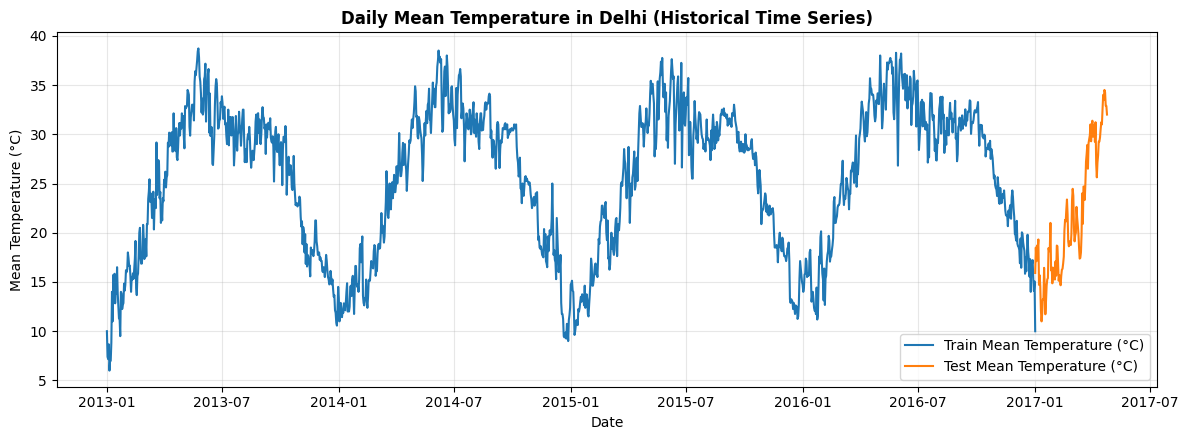

In [4]:
# ======================================================
# STEP 3: EXPLORATORY DATA ANALYSIS
# ======================================================
print("--- STEP 3: EXPLORATORY DATA ANALYSIS ---")

# Convert date column to datetime type
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

print("Missing values in Training Data:")
print(train_df.isnull().sum())

# Plot historical mean temperature over time
plt.figure(figsize=(12, 4.5))
plt.plot(train_df['date'], train_df['meantemp'], label='Train Mean Temperature (°C)', color='#1f77b4')
plt.plot(test_df['date'], test_df['meantemp'], label='Test Mean Temperature (°C)', color='#ff7f0e')
plt.title("Daily Mean Temperature in Delhi (Historical Time Series)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h2>Step 4: Data Normalization & Sequence Creation (Sliding Window)</h2>

### 💡 Why Feature Scaling & Sequences for RNNs?
1. <b>Feature Scaling (MinMaxScaler)</b>: Neural networks, especially RNNs, work best when input values are bounded between <code>0</code> and <code>1</code>. This speeds up convergence and prevents gradient exploding/vanishing.
2. <b>Sliding Window Sequences</b>:
   - To predict tomorrow's temperature, we give the model a sequence of the <b>past 30 days</b> of temperatures.
   - <b>Input ($X$)</b>: Shape <code>(seq_length = 30)</code> representing past 30 days.
   - <b>Target ($y$)</b>: Temperature on the 31st day!

In [5]:
# ======================================================
# STEP 4: DATA SCALING & SLIDING WINDOW SEQUENCES
# ======================================================
print("--- STEP 4: FEATURE SCALING & SEQUENCE CREATION ---")

# Extract temperature values
train_temps = train_df[['meantemp']].values
test_temps = test_df[['meantemp']].values

# Fit scaler on training data only
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_temps)

# Combine train tail + test so test set has the full 30-day lookback window
SEQ_LENGTH = 30
combined_test_temps = np.vstack((train_temps[-SEQ_LENGTH:], test_temps))
test_scaled = scaler.transform(combined_test_temps)

# Helper function to create sequence windows (X: past 30 days, y: next day)
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQ_LENGTH)

print(f"Training Sequences   - X shape: {X_train.shape}, y shape: {y_train.shape}")
print(f"Testing Sequences    - X shape: {X_test.shape}, y shape: {y_test.shape}")

--- STEP 4: FEATURE SCALING & SEQUENCE CREATION ---
Training Sequences   - X shape: (1432, 30, 1), y shape: (1432, 1)
Testing Sequences    - X shape: (114, 30, 1), y shape: (114, 1)


<h2>Step 5: PyTorch Dataset & DataLoaders</h2>

Now we wrap our Numpy sequences into PyTorch <code>TensorDataset</code> and <code>DataLoader</code> objects with <code>batch_size = 32</code>.

In [6]:
# ======================================================
# STEP 5: PYTORCH DATASET & DATALOADERS
# ======================================================
print("--- STEP 5: CREATING DATALOADERS ---")

# Convert Numpy arrays to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create TensorDatasets
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created with Batch Size = {BATCH_SIZE}!")

--- STEP 5: CREATING DATALOADERS ---
DataLoaders created with Batch Size = 32!


<h2>Step 6: Simple Recurrent Neural Network (RNN) Architecture</h2>

Here we build a beginner-friendly <b>Recurrent Neural Network (SimpleRNN)</b> in PyTorch.

### 💡 RNN Layer Parameters Explained:
- <b><code>nn.RNN(input_size=1, hidden_size=32, num_layers=1, batch_first=True)</code></b>:
  - <b><code>input_size=1</code></b>: We pass 1 feature (`meantemp`) per time step.
  - <b><code>hidden_size=32</code></b>: Number of hidden memory neurons carrying information across time steps.
  - <b><code>batch_first=True</code></b>: Tensor dimensions are <code>(batch_size, sequence_length, features)</code>.
- <b><code>nn.Linear(32, 1)</code></b>: Fully connected linear layer mapping the final hidden state output to a single temperature prediction.

In [7]:
# ======================================================
# STEP 6: SIMPLE RNN MODEL CLASS DEFINITION
# ======================================================
print("--- STEP 6: BUILDING RNN MODEL ARCHITECTURE ---")

class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super(SimpleRNN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Recurrent Neural Network Layer
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully Connected Output Layer
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # Initialize initial hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Pass input sequence through RNN layer
        out, _ = self.rnn(x, h0)
        
        # Take the output of the LAST time step (out[:, -1, :]) for prediction
        out = self.fc(out[:, -1, :])
        return out

# Instantiate model
model = SimpleRNN(input_size=1, hidden_size=32, num_layers=1, output_size=1).to(device)
print("RNN Model Architecture Summary:")
print(model)

--- STEP 6: BUILDING RNN MODEL ARCHITECTURE ---
RNN Model Architecture Summary:
SimpleRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


<h2>Step 7: Loss Function & Optimizer</h2>

For regression tasks (predicting continuous temperature values):
1. <b>Loss Function</b>: <code>nn.MSELoss()</code> (Mean Squared Error).
2. <b>Optimizer</b>: <code>torch.optim.Adam(model.parameters(), lr=0.001)</code>.

In [8]:
# ======================================================
# STEP 7: LOSS FUNCTION & OPTIMIZER SETUP
# ======================================================
print("--- STEP 7: SETTING UP LOSS & OPTIMIZER ---")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss Function: Mean Squared Error (MSELoss)")
print("Optimizer: Adam (learning rate = 0.001)")

--- STEP 7: SETTING UP LOSS & OPTIMIZER ---
Loss Function: Mean Squared Error (MSELoss)
Optimizer: Adam (learning rate = 0.001)


<h2>Step 8: Model Training & Loss Curves</h2>

We train the RNN for <b>30 Epochs</b> while tracking training loss to monitor convergence.

--- STEP 8: TRAINING RNN MODEL ---
Starting RNN Training Loop...
Epoch [01/30] | Training MSE Loss: 0.100080
Epoch [05/30] | Training MSE Loss: 0.003812
Epoch [10/30] | Training MSE Loss: 0.003562
Epoch [15/30] | Training MSE Loss: 0.003338
Epoch [20/30] | Training MSE Loss: 0.003350
Epoch [25/30] | Training MSE Loss: 0.003054
Epoch [30/30] | Training MSE Loss: 0.002979
RNN Training Complete!


<string>:48: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


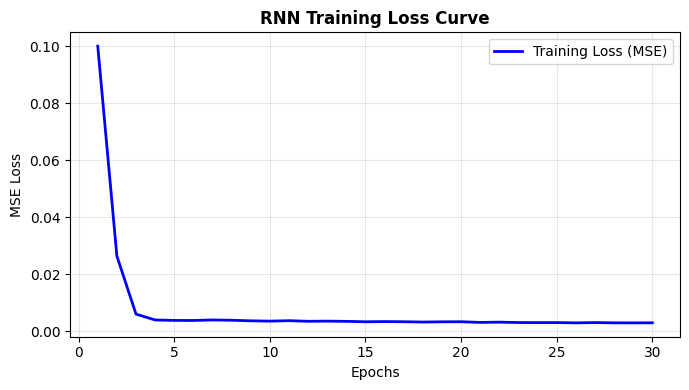

In [9]:
# ======================================================
# STEP 8: TRAINING THE RNN MODEL
# ======================================================
print("--- STEP 8: TRAINING RNN MODEL ---")

epochs = 30
train_losses = []

print("Starting RNN Training Loop...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for seq_batch, target_batch in train_loader:
        seq_batch, target_batch = seq_batch.to(device), target_batch.to(device)
        
        # Zero parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(seq_batch)
        loss = criterion(predictions, target_batch)
        
        # Backward pass & update weights
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * seq_batch.size(0)
        
    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{epochs}] | Training MSE Loss: {epoch_loss:.6f}")

print("RNN Training Complete!")

# Plot Training Loss Curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss (MSE)', color='blue', linewidth=2)
plt.title("RNN Training Loss Curve", fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h2>Step 9: Test Set Forecasting & Actual vs. Predicted Visualization</h2>

Now we evaluate the trained RNN model on the unseen <b>Test Set</b> (`DailyDelhiClimateTest.csv`).

We use <code>scaler.inverse_transform()</code> to convert normalized predictions back into real temperature values (°C) and plot <b>Actual vs. Predicted Temperatures</b>!

--- STEP 9: EVALUATING & FORECASTING ON TEST SET ---


<string>:32: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


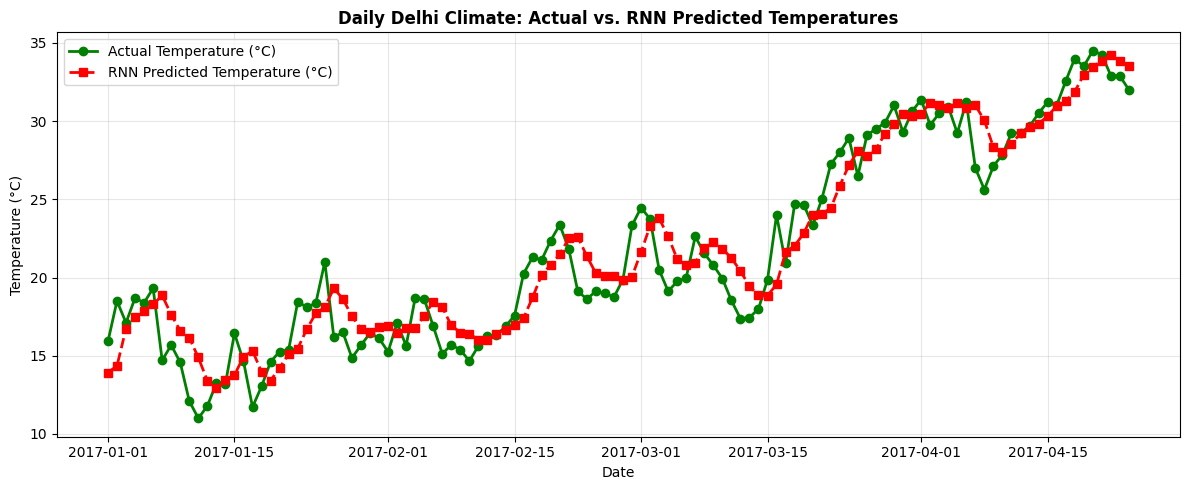

In [10]:
# ======================================================
# STEP 9: TEST EVALUATION & FORECAST PLOT
# ======================================================
print("--- STEP 9: EVALUATING & FORECASTING ON TEST SET ---")

model.eval()
predictions_list = []
actuals_list = []

with torch.no_grad():
    for seq_batch, target_batch in test_loader:
        seq_batch = seq_batch.to(device)
        preds = model(seq_batch)
        
        predictions_list.extend(preds.cpu().numpy())
        actuals_list.extend(target_batch.numpy())

# Convert back from scaled [0, 1] to original Temperature scale (°C)
actual_temps = scaler.inverse_transform(np.array(actuals_list))
predicted_temps = scaler.inverse_transform(np.array(predictions_list))

# Plot Actual vs Predicted Temperatures
plt.figure(figsize=(12, 5))
plt.plot(test_df['date'], actual_temps, label='Actual Temperature (°C)', color='green', linewidth=2, marker='o')
plt.plot(test_df['date'], predicted_temps, label='RNN Predicted Temperature (°C)', color='red', linestyle='--', linewidth=2, marker='s')
plt.title("Daily Delhi Climate: Actual vs. RNN Predicted Temperatures", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h2>Step 10: Evaluation Metrics (MSE, RMSE, MAE)</h2>

We evaluate our temperature forecasts using standard time-series regression metrics:
- <b>MSE (Mean Squared Error)</b>: Average squared error between actual and predicted temperatures.
- <b>RMSE (Root Mean Squared Error)</b>: Square root of MSE, representing error in actual temperature units (°C).
- <b>MAE (Mean Absolute Error)</b>: Average absolute error in °C.

In [11]:
# ======================================================
# STEP 10: CALCULATING METRICS & SUMMARY
# ======================================================
print("--- STEP 10: FORECAST EVALUATION METRICS ---")

mse = mean_squared_error(actual_temps, predicted_temps)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_temps, predicted_temps)

metrics_df = pd.DataFrame({
    'Evaluation Metric': ['Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)'],
    'Value': [f"{mse:.4f}", f"{rmse:.4f} °C", f"{mae:.4f} °C"]
})

print("="*55)
print("RNN TIME-SERIES FORECASTING PERFORMANCE")
print("="*55)
print(metrics_df.to_string(index=False))
print("="*55)

--- STEP 10: FORECAST EVALUATION METRICS ---
RNN TIME-SERIES FORECASTING PERFORMANCE
             Evaluation Metric     Value
      Mean Squared Error (MSE)    3.6316
Root Mean Squared Error (RMSE) 1.9057 °C
     Mean Absolute Error (MAE) 1.5338 °C
